In [9]:
!pip install "dacite~=1.6.0" mlflow dagshub xgboost scikit-learn -q

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import mlflow
import mlflow.sklearn
import dagshub
import xgboost as xgb
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectFromModel, VarianceThreshold
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, LabelEncoder, OrdinalEncoder

RANDOM_STATE = 42
REPO_OWNER = 'ejoba22'
REPO_NAME = 'IEEE-CIS-Fraud-Detection'
EXPERIMENT_NAME = 'XGBoost_Training'

dagshub.init(repo_owner=REPO_OWNER, repo_name=REPO_NAME, mlflow=True)

if mlflow.active_run() is not None:
    mlflow.end_run()

experiment = mlflow.set_experiment(EXPERIMENT_NAME)
EXPERIMENT_ID = experiment.experiment_id

print('MLflow experiment:', experiment.name)

Initialized MLflow to track repo "ejoba22/IEEE-CIS-Fraud-Detection"

Repository ejoba22/IEEE-CIS-Fraud-Detection initialized!

MLflow experiment: XGBoost_Training


In [11]:
def reduce_mem_usage(df):
    start_mem = df.memory_usage(deep=True).sum() / 1024**2

    for col in df.columns:
        col_type = df[col].dtype

        if col_type == object:
            continue

        c_min = df[col].min()
        c_max = df[col].max()

        if str(col_type).startswith('int'):
            if c_min >= np.iinfo(np.int8).min and c_max <= np.iinfo(np.int8).max:
                df[col] = df[col].astype(np.int8)
            elif c_min >= np.iinfo(np.int16).min and c_max <= np.iinfo(np.int16).max:
                df[col] = df[col].astype(np.int16)
            elif c_min >= np.iinfo(np.int32).min and c_max <= np.iinfo(np.int32).max:
                df[col] = df[col].astype(np.int32)
        elif str(col_type).startswith('float'):
            df[col] = df[col].astype(np.float32)

    end_mem = df.memory_usage(deep=True).sum() / 1024**2
    print(f'Memory reduced from {start_mem:.1f} MB to {end_mem:.1f} MB')
    return df


train_transaction = reduce_mem_usage(pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv'))
train_identity = reduce_mem_usage(pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv'))

train = train_transaction.merge(train_identity, on='TransactionID', how='left')
train = reduce_mem_usage(train)

print('Raw merged shape:', train.shape)

Memory reduced from 2062.1 MB to 1203.2 MB
Memory reduced from 143.1 MB to 129.9 MB
Memory reduced from 1603.3 MB to 1603.3 MB
Raw merged shape: (590540, 434)


# 1. Cleaning

In [12]:
train_sorted = train.sort_values('TransactionDT').reset_index(drop=True)
split_idx    = int(len(train_sorted) * 0.8)

df_tr  = train_sorted.iloc[:split_idx].copy()
df_val = train_sorted.iloc[split_idx:].copy()

print(f'Train rows: {len(df_tr):,}  |  Val rows: {len(df_val):,}')
print(f'Train fraud rate: {df_tr["isFraud"].mean():.4f}')
print(f'Val   fraud rate: {df_val["isFraud"].mean():.4f}')

Train rows: 472,432  |  Val rows: 118,108
Train fraud rate: 0.0351
Val   fraud rate: 0.0344


Columns dropped at each threshold:
  >50%  ->  drop 214, keep 220
  >75%  ->  drop 208, keep 226
  >90%  ->  drop 12, keep 422


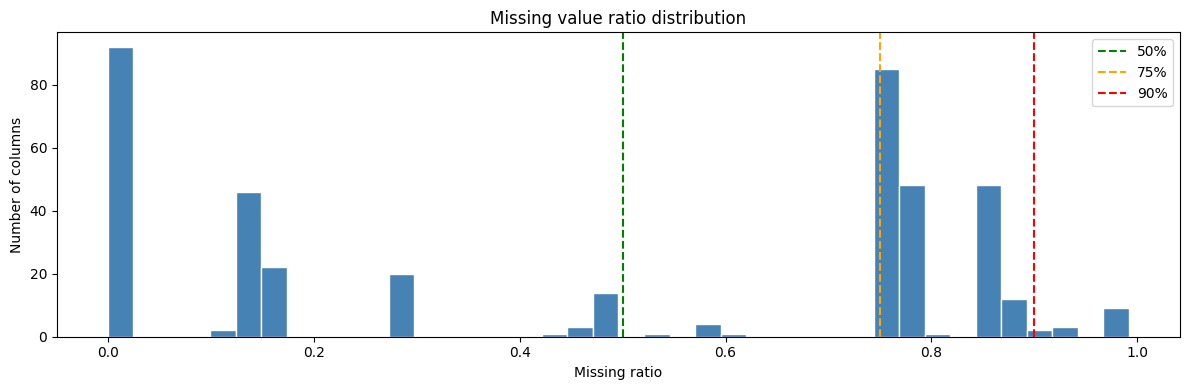

In [13]:
missing = train_sorted.isnull().mean().sort_values(ascending=False)

thresholds = [0.5, 0.75, 0.9]
print('Columns dropped at each threshold:')
for t in thresholds:
    print(f'  >{int(t*100)}%  ->  drop {(missing > t).sum()}, keep {(missing <= t).sum()}')

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(missing[missing > 0], bins=40, color='steelblue', edgecolor='white')
for t, c in zip(thresholds, ['green', 'orange', 'red']):
    ax.axvline(t, color=c, linestyle='--', linewidth=1.5, label=f'{int(t*100)}%')
ax.set_title('Missing value ratio distribution')
ax.set_xlabel('Missing ratio')
ax.set_ylabel('Number of columns')
ax.legend()
plt.tight_layout()
plt.savefig('missing_distribution.png', dpi=100)
plt.show()

In [14]:
def prepare_df(df, strategy, high_missing_cols, le_dict=None, fit=True):
    """
    Drops high-missing cols, encodes categoricals, applies numeric imputation.
    strategy: 'keep_nan' | 'median' | 'minus999' | 'median_indicator' | 'minus999_indicator'
    Returns (X, y, le_dict)
    """
    d = df.drop(columns=high_missing_cols + ['TransactionID', 'TransactionDT'], errors='ignore').copy()

    for col in d.select_dtypes('float64').columns:
        d[col] = d[col].astype('float32')
    for col in d.select_dtypes('int64').columns:
        d[col] = d[col].astype('int32')

    y = d.pop('isFraud')

    cat_cols = d.select_dtypes('object').columns.tolist()
    if fit:
        le_dict = {}
        for col in cat_cols:
            le = LabelEncoder()
            d[col] = d[col].fillna('__missing__')
            le.fit(d[col].astype(str))
            d[col] = le.transform(d[col].astype(str)).astype('float32')
            le_dict[col] = le
    else:
        for col in cat_cols:
            d[col] = d[col].fillna('__missing__')
            le = le_dict[col]
            d[col] = d[col].astype(str).map(
                lambda x, le=le: le.transform([x])[0] if x in le.classes_ else -1
            ).astype('float32')

    num_cols = d.select_dtypes(include=np.number).columns.tolist()

    if strategy == 'keep_nan':
        pass 

    elif strategy == 'median':
        if fit:
            medians = d[num_cols].median()
            le_dict['__medians__'] = medians
        for col in num_cols:
            d[col] = d[col].fillna(le_dict['__medians__'][col])

    elif strategy == 'minus999':
        d[num_cols] = d[num_cols].fillna(-999)

    elif strategy == 'median_indicator':
        if fit:
            medians = d[num_cols].median()
            le_dict['__medians__'] = medians
        for col in num_cols:
            if d[col].isnull().any():
                d[f'{col}_was_nan'] = d[col].isnull().astype('float32')
            d[col] = d[col].fillna(le_dict['__medians__'][col])

    elif strategy == 'minus999_indicator':
        for col in num_cols:
            if d[col].isnull().any():
                d[f'{col}_was_nan'] = d[col].isnull().astype('float32')
        d[num_cols] = d[num_cols].fillna(-999)

    return d, y, le_dict


# Small fast XGBoost for cleaning experiments not the final tuned model
BASELINE_PARAMS = dict(
    n_estimators      = 100,
    max_depth         = 4,
    learning_rate     = 0.1,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    eval_metric       = 'auc',
    random_state      = RANDOM_STATE,
    n_jobs            = -1
)

print('done')

done


In [15]:
threshold_results = []

for threshold in thresholds:
    run_name = f'XGBoost_Cleaning_threshold_{int(threshold*100)}pct'

    with mlflow.start_run(experiment_id=EXPERIMENT_ID, run_name=run_name):

        high_missing_cols = missing[missing > threshold].index.tolist()

        X_tr,  y_tr,  le_dict = prepare_df(df_tr,  'median', high_missing_cols, fit=True)
        X_val, y_val, _       = prepare_df(df_val, 'median', high_missing_cols, le_dict=le_dict, fit=False)

        X_val = X_val.reindex(columns=X_tr.columns, fill_value=0)

        scale_pos = (y_tr == 0).sum() / (y_tr == 1).sum()
        model = xgb.XGBClassifier(**BASELINE_PARAMS, scale_pos_weight=scale_pos)
        model.fit(X_tr, y_tr, verbose=False)

        train_auc = roc_auc_score(y_tr,  model.predict_proba(X_tr)[:, 1])
        val_auc   = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])
        gap       = round(train_auc - val_auc, 4)

        mlflow.log_param('missing_threshold',  threshold)
        mlflow.log_param('dropped_cols',       len(high_missing_cols))
        mlflow.log_param('remaining_cols',     X_tr.shape[1])
        mlflow.log_param('imputation',         'median (fixed for threshold experiment)')
        mlflow.log_metric('train_auc',         round(train_auc, 4))
        mlflow.log_metric('val_auc',           round(val_auc, 4))
        mlflow.log_metric('overfit_gap',       gap)
        mlflow.log_artifact('missing_distribution.png')

        threshold_results.append({
            'threshold':   f'{int(threshold*100)}%',
            'dropped':     len(high_missing_cols),
            'kept':        X_tr.shape[1],
            'train_auc':   round(train_auc, 4),
            'val_auc':     round(val_auc, 4),
            'overfit_gap': gap
        })

        print(f'[{int(threshold*100)}%] dropped={len(high_missing_cols)}  '
              f'train_auc={train_auc:.4f}  val_auc={val_auc:.4f}  gap={gap:.4f}')

print('\n', pd.DataFrame(threshold_results).to_string(index=False))

[50%] dropped=214  train_auc=0.9094  val_auc=0.8887  gap=0.0207
🏃 View run XGBoost_Cleaning_threshold_50pct at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/c6a1da90bb6b49a0940e0f84b3ec4838
🧪 View experiment at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0
[75%] dropped=208  train_auc=0.9095  val_auc=0.8864  gap=0.0231
🏃 View run XGBoost_Cleaning_threshold_75pct at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/65c24df0278d444cac38d0118ec16348
🧪 View experiment at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0
[90%] dropped=12  train_auc=0.9094  val_auc=0.8861  gap=0.0233
🏃 View run XGBoost_Cleaning_threshold_90pct at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/2f0d9f483c974e54b221044318d2376e
🧪 View experiment at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0

 threshold  dropped  kept  t

# 2. Feature Engineering

In [16]:
CHOSEN_THRESHOLD = 0.50
CHOSEN_IMPUTATION = 'median'

high_missing_cols = missing[missing > CHOSEN_THRESHOLD].index.tolist()


def add_engineered_features(d, feature_set='time_amount'):
    d = d.copy()

    if feature_set in ['time_amount', 'time_amount_freq']:
        if 'TransactionDT' in d.columns:
            seconds_in_day = 24 * 60 * 60
            d['Transaction_hour'] = (d['TransactionDT'] // 3600) % 24
            d['Transaction_day'] = d['TransactionDT'] // seconds_in_day
            d['Transaction_week'] = d['Transaction_day'] // 7

        if 'TransactionAmt' in d.columns:
            d['TransactionAmt_log'] = np.log1p(d['TransactionAmt'])
            d['TransactionAmt_cents'] = ((d['TransactionAmt'] - np.floor(d['TransactionAmt'])) * 100).round()

    if feature_set == 'time_amount_freq':
        if {'card1', 'addr1'}.issubset(d.columns):
            d['card1_addr1'] = d['card1'].astype(str) + '_' + d['addr1'].astype(str)
        if {'P_emaildomain', 'R_emaildomain'}.issubset(d.columns):
            d['same_email_domain'] = (d['P_emaildomain'].astype(str) == d['R_emaildomain'].astype(str)).astype('float32')

    return d


def prepare_feature_df(df, strategy, high_missing_cols, feature_set='baseline', state=None, fit=True):
    d = df.drop(columns=high_missing_cols + ['TransactionID'], errors='ignore').copy()
    d = add_engineered_features(d, feature_set=feature_set)

    y = d.pop('isFraud') if 'isFraud' in d.columns else None
    d = d.drop(columns=['TransactionDT'], errors='ignore')

    if fit:
        state = {'category_maps': {}, 'medians': None, 'freq_maps': {}}

    cat_cols = d.select_dtypes(include='object').columns.tolist()

    if feature_set == 'time_amount_freq':
        for col in cat_cols:
            if fit:
                state['freq_maps'][col] = d[col].fillna('__missing__').astype(str).value_counts(normalize=True)
            d[f'{col}_freq'] = d[col].fillna('__missing__').astype(str).map(state['freq_maps'][col]).fillna(0).astype('float32')

    for col in cat_cols:
        values = d[col].fillna('__missing__').astype(str)
        if fit:
            categories = pd.Index(values.unique())
            state['category_maps'][col] = {value: i for i, value in enumerate(categories)}
        d[col] = values.map(state['category_maps'][col]).fillna(-1).astype('float32')

    for col in d.select_dtypes('float64').columns:
        d[col] = d[col].astype('float32')
    for col in d.select_dtypes('int64').columns:
        d[col] = d[col].astype('int32')

    num_cols = d.select_dtypes(include=np.number).columns.tolist()

    if strategy == 'keep_nan':
        pass
    elif strategy == 'median':
        if fit:
            state['medians'] = d[num_cols].median()
        d[num_cols] = d[num_cols].fillna(state['medians'])
    elif strategy == 'minus999':
        d[num_cols] = d[num_cols].fillna(-999)
    elif strategy == 'median_indicator':
        if fit:
            state['medians'] = d[num_cols].median()
            state['indicator_cols'] = [col for col in num_cols if d[col].isnull().any()]
        for col in state['indicator_cols']:
            d[f'{col}_was_nan'] = d[col].isnull().astype('float32')
        d[num_cols] = d[num_cols].fillna(state['medians'])
    else:
        raise ValueError(f'Unknown strategy: {strategy}')

    return d, y, state


def fit_eval_xgb(X_tr, y_tr, X_val, y_val, params=None):
    params = params or BASELINE_PARAMS
    scale_pos = (y_tr == 0).sum() / (y_tr == 1).sum()
    model = xgb.XGBClassifier(**params, scale_pos_weight=scale_pos)
    model.fit(X_tr, y_tr, verbose=False)

    train_auc = roc_auc_score(y_tr, model.predict_proba(X_tr)[:, 1])
    val_auc = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])
    return model, train_auc, val_auc

print('Feature engineering helpers ready.')

Feature engineering helpers ready.


In [17]:
BASELINE_PARAMS.update({
    'tree_method': 'hist',
    'predictor': 'cuda'
})
print('done')

done


In [18]:
feature_sets = ['baseline', 'time_amount', 'time_amount_freq']
feature_results = []
feature_artifacts = {}

for feature_set in feature_sets:
    run_name = f'XGBoost_Feature_Engineering_{feature_set}'

    with mlflow.start_run(experiment_id=EXPERIMENT_ID, run_name=run_name):
        X_tr, y_tr, state = prepare_feature_df(
            df_tr,
            CHOSEN_IMPUTATION,
            high_missing_cols,
            feature_set=feature_set,
            fit=True
        )
        X_val, y_val, _ = prepare_feature_df(
            df_val,
            CHOSEN_IMPUTATION,
            high_missing_cols,
            feature_set=feature_set,
            state=state,
            fit=False
        )
        X_val = X_val.reindex(columns=X_tr.columns, fill_value=0)

        model, train_auc, val_auc = fit_eval_xgb(X_tr, y_tr, X_val, y_val)
        gap = train_auc - val_auc

        mlflow.log_param('missing_threshold', CHOSEN_THRESHOLD)
        mlflow.log_param('imputation', CHOSEN_IMPUTATION)
        mlflow.log_param('feature_set', feature_set)
        mlflow.log_param('n_features', X_tr.shape[1])
        mlflow.log_metric('train_auc', round(train_auc, 4))
        mlflow.log_metric('val_auc', round(val_auc, 4))
        mlflow.log_metric('overfit_gap', round(gap, 4))

        feature_results.append({
            'feature_set': feature_set,
            'n_features': X_tr.shape[1],
            'train_auc': round(train_auc, 4),
            'val_auc': round(val_auc, 4),
            'overfit_gap': round(gap, 4)
        })
        feature_artifacts[feature_set] = (X_tr, y_tr, X_val, y_val, model)

        print(f'[{feature_set}] features={X_tr.shape[1]} train_auc={train_auc:.4f} val_auc={val_auc:.4f} gap={gap:.4f}')

feature_results_df = pd.DataFrame(feature_results).sort_values('val_auc', ascending=False)
BEST_FEATURE_SET = feature_results_df.iloc[0]['feature_set']
print('\nBest feature set:', BEST_FEATURE_SET)
print(feature_results_df.to_string(index=False))

[baseline] features=217 train_auc=0.9098 val_auc=0.8873 gap=0.0226
🏃 View run XGBoost_Feature_Engineering_baseline at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/697682fb167347fdb36ac8e3da3cb50b
🧪 View experiment at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0
[time_amount] features=222 train_auc=0.9123 val_auc=0.8850 gap=0.0273
🏃 View run XGBoost_Feature_Engineering_time_amount at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/fbc6598aec854c48a3ae8284b34eea3e
🧪 View experiment at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0
[time_amount_freq] features=233 train_auc=0.9145 val_auc=0.8859 gap=0.0286
🏃 View run XGBoost_Feature_Engineering_time_amount_freq at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/167024bb1bdd4f8fa6c9ac3b1d14044e
🧪 View experiment at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#

# 3. Feature Selection
   

In [19]:
#feature selection variants

X_tr_full, y_tr_full, X_val_full, y_val_full, fe_model = feature_artifacts[BEST_FEATURE_SET]

importance = pd.Series(fe_model.feature_importances_, index=X_tr_full.columns).sort_values(ascending=False)
importance.to_csv('xgboost_feature_importance.csv')

selection_results = []
selected_feature_sets = {'all_features': X_tr_full.columns.tolist()}

selection_configs = [('all_features', None), ('top_100_importance', 100), ('top_200_importance', 200), ('top_300_importance', 300)]

for selection_name, top_n in selection_configs:
    run_name = f'XGBoost_Feature_Selection_{selection_name}'

    with mlflow.start_run(experiment_id=EXPERIMENT_ID, run_name=run_name):
        if top_n is None:
            cols = X_tr_full.columns.tolist()
        else:
            cols = importance.head(min(top_n, len(importance))).index.tolist()

        X_tr_sel = X_tr_full[cols]
        X_val_sel = X_val_full[cols]
        model, train_auc, val_auc = fit_eval_xgb(X_tr_sel, y_tr_full, X_val_sel, y_val_full)
        gap = train_auc - val_auc

        mlflow.log_param('feature_set', BEST_FEATURE_SET)
        mlflow.log_param('selection_method', selection_name)
        mlflow.log_param('n_selected_features', len(cols))
        mlflow.log_metric('train_auc', round(train_auc, 4))
        mlflow.log_metric('val_auc', round(val_auc, 4))
        mlflow.log_metric('overfit_gap', round(gap, 4))
        mlflow.log_artifact('xgboost_feature_importance.csv')

        selection_results.append({
            'selection_method': selection_name,
            'n_features': len(cols),
            'train_auc': round(train_auc, 4),
            'val_auc': round(val_auc, 4),
            'overfit_gap': round(gap, 4)
        })
        selected_feature_sets[selection_name] = cols

        print(f'[{selection_name}] features={len(cols)} train_auc={train_auc:.4f} val_auc={val_auc:.4f} gap={gap:.4f}')

selection_results_df = pd.DataFrame(selection_results).sort_values('val_auc', ascending=False)
BEST_SELECTION = selection_results_df.iloc[0]['selection_method']
BEST_FEATURES = selected_feature_sets[BEST_SELECTION]

print('\nBest selection:', BEST_SELECTION)
print(selection_results_df.to_string(index=False))

[all_features] features=217 train_auc=0.9098 val_auc=0.8873 gap=0.0226
🏃 View run XGBoost_Feature_Selection_all_features at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/9bd086454db34b57973c14d735738c33
🧪 View experiment at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0
[top_100_importance] features=100 train_auc=0.9089 val_auc=0.8865 gap=0.0224
🏃 View run XGBoost_Feature_Selection_top_100_importance at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/921c0739243e47ca9ac47fa27c5493af
🧪 View experiment at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0
[top_200_importance] features=200 train_auc=0.9097 val_auc=0.8874 gap=0.0223
🏃 View run XGBoost_Feature_Selection_top_200_importance at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/6f5e1cb9759b4691a16ecafbf7aa72ee
🧪 View experiment at: https://dagshub.com/ejoba22/IEEE-CIS-Frau

# 4. Cross Validation

In [20]:
with mlflow.start_run(experiment_id=EXPERIMENT_ID, run_name='XGBoost_CrossValidation_TimeSeriesSplit'):
    X_all, y_all, state_all = prepare_feature_df(
        train_sorted,
        CHOSEN_IMPUTATION,
        high_missing_cols,
        feature_set=BEST_FEATURE_SET,
        fit=True
    )
    X_all = X_all.reindex(columns=X_tr_full.columns, fill_value=0)
    X_all = X_all[BEST_FEATURES]

    tscv = TimeSeriesSplit(n_splits=3)
    fold_scores = []

    for fold, (train_idx, valid_idx) in enumerate(tscv.split(X_all), start=1):
        X_fold_tr = X_all.iloc[train_idx]
        y_fold_tr = y_all.iloc[train_idx]
        X_fold_val = X_all.iloc[valid_idx]
        y_fold_val = y_all.iloc[valid_idx]

        model, train_auc, val_auc = fit_eval_xgb(X_fold_tr, y_fold_tr, X_fold_val, y_fold_val)
        fold_scores.append(val_auc)

        mlflow.log_metric(f'fold_{fold}_train_auc', round(train_auc, 4))
        mlflow.log_metric(f'fold_{fold}_val_auc', round(val_auc, 4))
        print(f'[fold {fold}] train_auc={train_auc:.4f} val_auc={val_auc:.4f}')

    mlflow.log_param('feature_set', BEST_FEATURE_SET)
    mlflow.log_param('selection_method', BEST_SELECTION)
    mlflow.log_param('n_selected_features', len(BEST_FEATURES))
    mlflow.log_metric('cv_mean_auc', round(float(np.mean(fold_scores)), 4))
    mlflow.log_metric('cv_std_auc', round(float(np.std(fold_scores)), 4))

print('CV mean AUC:', round(float(np.mean(fold_scores)), 4))
print('CV std AUC:', round(float(np.std(fold_scores)), 4))

[fold 1] train_auc=0.9345 val_auc=0.8782
[fold 2] train_auc=0.9191 val_auc=0.8864
[fold 3] train_auc=0.9096 val_auc=0.8877
🏃 View run XGBoost_CrossValidation_TimeSeriesSplit at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/9833cc14af4f442fbc708907daacdea6
🧪 View experiment at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0
CV mean AUC: 0.8841
CV std AUC: 0.0042


# 5. Training

In [21]:
training_param_grid = {
    'baseline': dict(BASELINE_PARAMS),
    'regularized': dict(
        BASELINE_PARAMS,
        n_estimators=250,
        max_depth=4,
        learning_rate=0.05,
        min_child_weight=5,
        reg_alpha=0.1,
        reg_lambda=2.0,
        subsample=0.8,
        colsample_bytree=0.8
    ),
    'deeper_overfit_check': dict(
        BASELINE_PARAMS,
        n_estimators=300,
        max_depth=8,
        learning_rate=0.08,
        min_child_weight=1,
        reg_lambda=1.0
    ),
    'shallow_underfit_check': dict(
        BASELINE_PARAMS,
        n_estimators=80,
        max_depth=2,
        learning_rate=0.05,
        min_child_weight=10,
        reg_lambda=5.0
    )
}

MAX_ACCEPTABLE_GAP = 0.05
GAP_PENALTY_WEIGHT = 0.25

training_results = []
best_model = None
best_selection_score = -np.inf
best_params_name = None
best_val_auc = -np.inf
best_val_auc_name = None

X_tr_train = X_tr_full[BEST_FEATURES]
X_val_train = X_val_full[BEST_FEATURES]

for params_name, params in training_param_grid.items():
    run_name = f'XGBoost_Training_{params_name}'

    with mlflow.start_run(experiment_id=EXPERIMENT_ID, run_name=run_name):
        model, train_auc, val_auc = fit_eval_xgb(X_tr_train, y_tr_full, X_val_train, y_val_full, params=params)
        gap = train_auc - val_auc
        overfit_penalty = max(0, gap - MAX_ACCEPTABLE_GAP) * GAP_PENALTY_WEIGHT
        selection_score = val_auc - overfit_penalty

        if gap > MAX_ACCEPTABLE_GAP:
            model_behavior = 'overfit_candidate'
        elif train_auc < 0.88 and val_auc < 0.87:
            model_behavior = 'underfit_candidate'
        else:
            model_behavior = 'generalization_candidate'

        mlflow.log_params(params)
        mlflow.log_param('feature_set', BEST_FEATURE_SET)
        mlflow.log_param('selection_method', BEST_SELECTION)
        mlflow.log_param('n_selected_features', len(BEST_FEATURES))
        mlflow.log_param('model_behavior', model_behavior)
        mlflow.log_param('max_acceptable_gap', MAX_ACCEPTABLE_GAP)
        mlflow.log_param('gap_penalty_weight', GAP_PENALTY_WEIGHT)
        mlflow.log_metric('train_auc', round(train_auc, 4))
        mlflow.log_metric('val_auc', round(val_auc, 4))
        mlflow.log_metric('overfit_gap', round(gap, 4))
        mlflow.log_metric('selection_score', round(selection_score, 4))

        training_results.append({
            'params_name': params_name,
            'train_auc': round(train_auc, 4),
            'val_auc': round(val_auc, 4),
            'overfit_gap': round(gap, 4),
            'selection_score': round(selection_score, 4),
            'model_behavior': model_behavior
        })

        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_val_auc_name = params_name

        print(
            f'[{params_name}] train_auc={train_auc:.4f} val_auc={val_auc:.4f} '
            f'gap={gap:.4f} selection_score={selection_score:.4f} behavior={model_behavior}'
        )

training_results_df = pd.DataFrame(training_results)
training_by_val_auc = training_results_df.sort_values('val_auc', ascending=False)
training_by_selection = training_results_df.sort_values('selection_score', ascending=False)

generalization_results = training_results_df[
    training_results_df['model_behavior'] == 'generalization_candidate'
].copy()

if len(generalization_results) > 0:
    final_choice = generalization_results.sort_values('val_auc', ascending=False).iloc[0]
    final_selection_reason = 'best validation AUC among generalization candidates'
else:
    final_choice = training_by_selection.iloc[0]
    final_selection_reason = 'fallback to best penalized selection_score because no generalization candidate existed'

best_params_name = final_choice['params_name']
BEST_PARAMS = training_param_grid[best_params_name]
best_selection_score = final_choice['selection_score']

print('\nBest raw validation AUC:', best_val_auc_name)
print(training_by_val_auc.to_string(index=False))
print('\nSelected final params:', best_params_name)
print('Selection reason:', final_selection_reason)
print(training_by_selection.to_string(index=False))

[baseline] train_auc=0.9097 val_auc=0.8874 gap=0.0223 selection_score=0.8874 behavior=generalization_candidate
🏃 View run XGBoost_Training_baseline at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/f99182cc6fe747b69fddd4354e3af590
🧪 View experiment at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0
[regularized] train_auc=0.9154 val_auc=0.8918 gap=0.0236 selection_score=0.8918 behavior=generalization_candidate
🏃 View run XGBoost_Training_regularized at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/61921c40e81d42ea8f5be57aa58f67bd
🧪 View experiment at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0
[deeper_overfit_check] train_auc=0.9891 val_auc=0.9018 gap=0.0873 selection_score=0.8925 behavior=overfit_candidate
🏃 View run XGBoost_Training_deeper_overfit_check at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/552e4c4ab6e7433e

In [22]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline

required_final_vars = [
    'CHOSEN_THRESHOLD',
    'CHOSEN_IMPUTATION',
    'BEST_FEATURE_SET',
    'BEST_SELECTION',
    'BEST_FEATURES',
    'BEST_PARAMS',
    'best_params_name',
    'final_selection_reason',
    'add_engineered_features',
    'df_tr',
    'df_val',
    'y_tr_full',
    'EXPERIMENT_ID'
]
missing_final_vars = [name for name in required_final_vars if name not in globals()]

if missing_final_vars:
    raise RuntimeError(
        'Run the notebook from the top before registering the final pipeline. '
        f'Missing variables: {missing_final_vars}'
    )


class IEEEFraudPreprocessor(BaseEstimator, TransformerMixin):
    def __init__(self, missing_threshold=0.5, imputation='median', feature_set='time_amount_freq', selected_features=None):
        self.missing_threshold = missing_threshold
        self.imputation = imputation
        self.feature_set = feature_set
        self.selected_features = selected_features

    def fit(self, X, y=None):
        X = X.copy()
        self.drop_cols_ = X.isnull().mean()[X.isnull().mean() > self.missing_threshold].index.tolist()
        self.drop_cols_ = [col for col in self.drop_cols_ if col not in ['isFraud']]

        d = X.drop(columns=self.drop_cols_ + ['TransactionID'], errors='ignore')
        d = add_engineered_features(d, feature_set=self.feature_set)
        d = d.drop(columns=['isFraud', 'TransactionDT'], errors='ignore')

        self.category_maps_ = {}
        self.freq_maps_ = {}
        self.cat_cols_ = d.select_dtypes(include='object').columns.tolist()

        if self.feature_set == 'time_amount_freq':
            for col in self.cat_cols_:
                self.freq_maps_[col] = d[col].fillna('__missing__').astype(str).value_counts(normalize=True)

        for col in self.cat_cols_:
            values = d[col].fillna('__missing__').astype(str)
            self.category_maps_[col] = {value: i for i, value in enumerate(pd.Index(values.unique()))}

        d = self._transform_without_selection(X)
        self.all_feature_columns_ = d.columns.tolist()

        if self.imputation in ['median', 'median_indicator']:
            self.medians_ = d.median(numeric_only=True)
        else:
            self.medians_ = None

        return self

    def _transform_without_selection(self, X):
        d = X.drop(columns=self.drop_cols_ + ['TransactionID'], errors='ignore').copy()
        d = add_engineered_features(d, feature_set=self.feature_set)
        d = d.drop(columns=['isFraud', 'TransactionDT'], errors='ignore')

        if self.feature_set == 'time_amount_freq':
            for col in self.cat_cols_:
                if col in d.columns:
                    d[f'{col}_freq'] = d[col].fillna('__missing__').astype(str).map(self.freq_maps_[col]).fillna(0).astype('float32')

        for col in self.cat_cols_:
            if col in d.columns:
                values = d[col].fillna('__missing__').astype(str)
                d[col] = values.map(self.category_maps_[col]).fillna(-1).astype('float32')

        for col in d.select_dtypes('float64').columns:
            d[col] = d[col].astype('float32')
        for col in d.select_dtypes('int64').columns:
            d[col] = d[col].astype('int32')

        d = d.reindex(columns=getattr(self, 'all_feature_columns_', d.columns), fill_value=np.nan)
        return d

    def transform(self, X):
        d = self._transform_without_selection(X)
        num_cols = d.select_dtypes(include=np.number).columns.tolist()

        if self.imputation == 'median':
            d[num_cols] = d[num_cols].fillna(self.medians_)
        elif self.imputation == 'minus999':
            d[num_cols] = d[num_cols].fillna(-999)
        elif self.imputation == 'median_indicator':
            missing_cols = [col for col in num_cols if d[col].isnull().any()]
            for col in missing_cols:
                d[f'{col}_was_nan'] = d[col].isnull().astype('float32')
            d[num_cols] = d[num_cols].fillna(self.medians_)
        elif self.imputation == 'keep_nan':
            pass
        else:
            raise ValueError(f'Unknown imputation: {self.imputation}')

        if self.selected_features is not None:
            d = d.reindex(columns=self.selected_features, fill_value=0)

        return d


final_pipeline = Pipeline(steps=[
    ('preprocess', IEEEFraudPreprocessor(
        missing_threshold=CHOSEN_THRESHOLD,
        imputation=CHOSEN_IMPUTATION,
        feature_set=BEST_FEATURE_SET,
        selected_features=BEST_FEATURES
    )),
    ('model', xgb.XGBClassifier(**BEST_PARAMS, scale_pos_weight=(y_tr_full == 0).sum() / (y_tr_full == 1).sum()))
])

with mlflow.start_run(experiment_id=EXPERIMENT_ID, run_name='XGBoost_Final_Pipeline_Register'):
    X_train_raw = df_tr.drop(columns=['isFraud'])
    y_train_raw = df_tr['isFraud']
    X_val_raw = df_val.drop(columns=['isFraud'])
    y_val_raw = df_val['isFraud']

    final_pipeline.fit(X_train_raw, y_train_raw)
    train_pred = final_pipeline.predict_proba(X_train_raw)[:, 1]
    val_pred = final_pipeline.predict_proba(X_val_raw)[:, 1]

    final_train_auc = roc_auc_score(y_train_raw, train_pred)
    final_val_auc = roc_auc_score(y_val_raw, val_pred)
    final_gap = final_train_auc - final_val_auc

    mlflow.log_param('final_feature_set', BEST_FEATURE_SET)
    mlflow.log_param('final_selection_method', BEST_SELECTION)
    mlflow.log_param('final_params_name', best_params_name)
    mlflow.log_param('final_selection_reason', final_selection_reason)
    mlflow.log_param('missing_threshold', CHOSEN_THRESHOLD)
    mlflow.log_param('imputation', CHOSEN_IMPUTATION)
    mlflow.log_param('n_selected_features', len(BEST_FEATURES))
    mlflow.log_metric('train_auc', round(final_train_auc, 4))
    mlflow.log_metric('val_auc', round(final_val_auc, 4))
    mlflow.log_metric('overfit_gap', round(final_gap, 4))

    mlflow.sklearn.log_model(
        sk_model=final_pipeline,
        artifact_path='xgboost_pipeline',
        registered_model_name='IEEE_CIS_XGBoost_Best'
    )

print(f'Final pipeline train_auc={final_train_auc:.4f} val_auc={final_val_auc:.4f} gap={final_gap:.4f}')
print('Registered model name: IEEE_CIS_XGBoost_Best')

2026/05/03 17:41:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/03 17:41:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'IEEE_CIS_XGBoost_Best'.
2026/05/03 17:42:05 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: IEEE_CIS_XGBoost_Best, version 1
Created version '1' of model 'IEEE_CIS_XGBoost_Best'.


🏃 View run XGBoost_Final_Pipeline_Register at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/1d4edde001624e66a7e06389e80a552f
🧪 View experiment at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0
Final pipeline train_auc=0.9148 val_auc=0.8924 gap=0.0224
Registered model name: IEEE_CIS_XGBoost_Best
